Computing true lyapunov exponents for the saddle node system moving average model. 

In [1]:
import os
import sys
from torchdiffeq import odeint as odeint

sys.path.append("/Users/jackr/Documents/GitHub/JackRoss-PhD-Notes")

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib import colors
from mpl_toolkits import mplot3d
from numpy import linalg as la
from scipy import stats
from scipy import spatial as sp
from scipy import integrate as integ
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
from ipywidgets import interact, IntSlider
import types
import lyapynov as lya 

import multiprocessing as mp

import models.DynamicalSystems as ds

import models.Neural_ODEs_v2 as nodes

In [409]:
torch.ones(1, 3, 1, dtype=torch.float32).shape

torch.Size([1, 3, 1])

# Theoretical

In [2]:
r0 = 0.01
le_function = lambda a: -2*a**(1/2) 

a_function = lambda t: -r0*t + 0.5

    

In [3]:
def ma_ed_function(T, t_delay):
    t0 = T - t_delay
    a_t0 = a_function(t0)
    a_T = a_function(T)
    num = 4*(a_T**(3/2) - a_t0**(3/2))
    dem = 3*r0*(t_delay)
    return num/dem

In [4]:
a_pts = torch.arange(0.0, 0.5, 0.001)
t_pts = torch.arange(0.0, 50.0, 0.01)

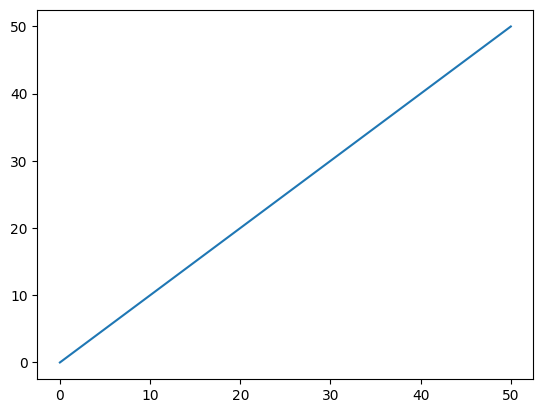

In [5]:
plt.plot(t_pts, t_pts) 

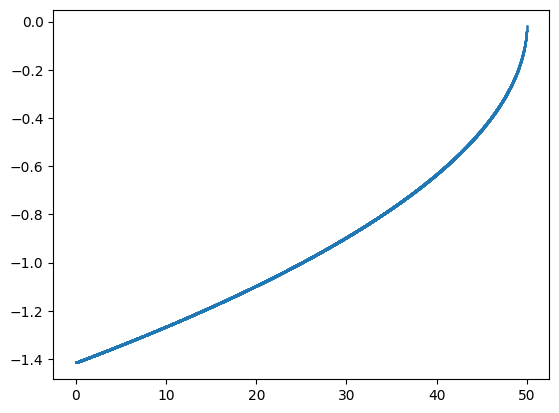

In [6]:
plt.plot(t_pts, le_function(a_function(t_pts)), linestyle='', marker='o', markersize = 1, label='True Lyapunov Exponent - Frozen Parameter')

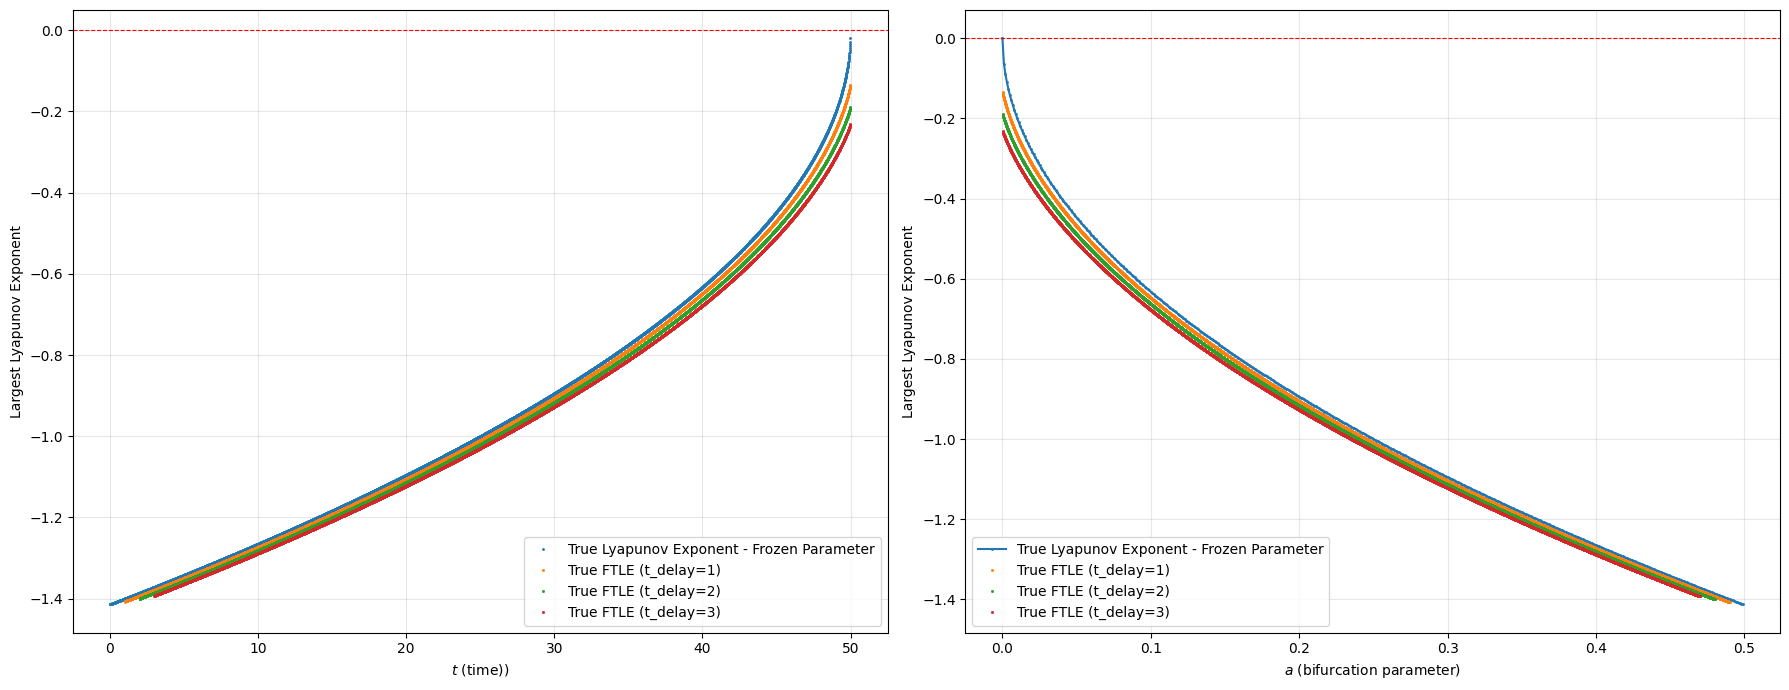

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left plot - Full view
axes[0].plot(t_pts, le_function(a_function(t_pts)), linestyle='', marker='o', markersize = 1, label='True Lyapunov Exponent - Frozen Parameter')


for i in range(1, 4):
    t_delay = i
    ma_ed_func_T = lambda T: ma_ed_function(T, t_delay=t_delay)
    t_pts_delay = torch.arange(t_delay, 50.0, 0.01)
    axes[0].plot(t_pts_delay, ma_ed_func_T(t_pts_delay), linestyle='', marker='s', markersize = 1, label=f'True FTLE (t_delay={t_delay})')

axes[0].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[0].set_ylabel('Largest Lyapunov Exponent')
axes[0].set_xlabel(r'$t$ (time))')
axes[0].grid(True, alpha=0.3)
axes[0].legend()


axes[1].plot(a_pts, le_function(a_pts), linestyle='-', marker='o', markersize = 1, label='True Lyapunov Exponent - Frozen Parameter')
for i in range(1, 4):
    t_delay = i
    ma_ed_func_T = lambda T: ma_ed_function(T, t_delay=t_delay)
    t_pts_delay = torch.arange(t_delay, 50.0, 0.01)
    axes[1].plot(a_function(t_pts_delay), ma_ed_func_T(t_pts_delay), linestyle='', marker='s', markersize = 1, label=f'True FTLE (t_delay={t_delay})')

axes[1].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[1].set_ylabel('Largest Lyapunov Exponent')
axes[1].set_xlabel(r'$a$ (bifurcation parameter)')
#axes[1].set_xlim(0.0, 0.1)

axes[1].grid(True, alpha=0.3)
axes[1].legend()


plt.tight_layout()
plt.show()

# Numerical

In [8]:
device = torch.device("cpu")

In [9]:
init_tensor = torch.load("data/05-03-26-saddle_node_init_tensor.pt", map_location=device)
lle_tensor = torch.load("data/05-03-26-saddle_node_lle_tensor.pt", map_location=device)
L_values = torch.load("data/05-03-26-saddle_node_L_values.pt", map_location=device)

In [10]:
# Build axes values from numerical tensors
a_pts = init_tensor[:, 1].detach().cpu()



dadt = -0.01 # From previous fill
t_func = lambda a: (a - 0.5)/dadt
t_pts = t_func(a_pts)

In [11]:
lle_tensor.shape

torch.Size([3, 50, 1])

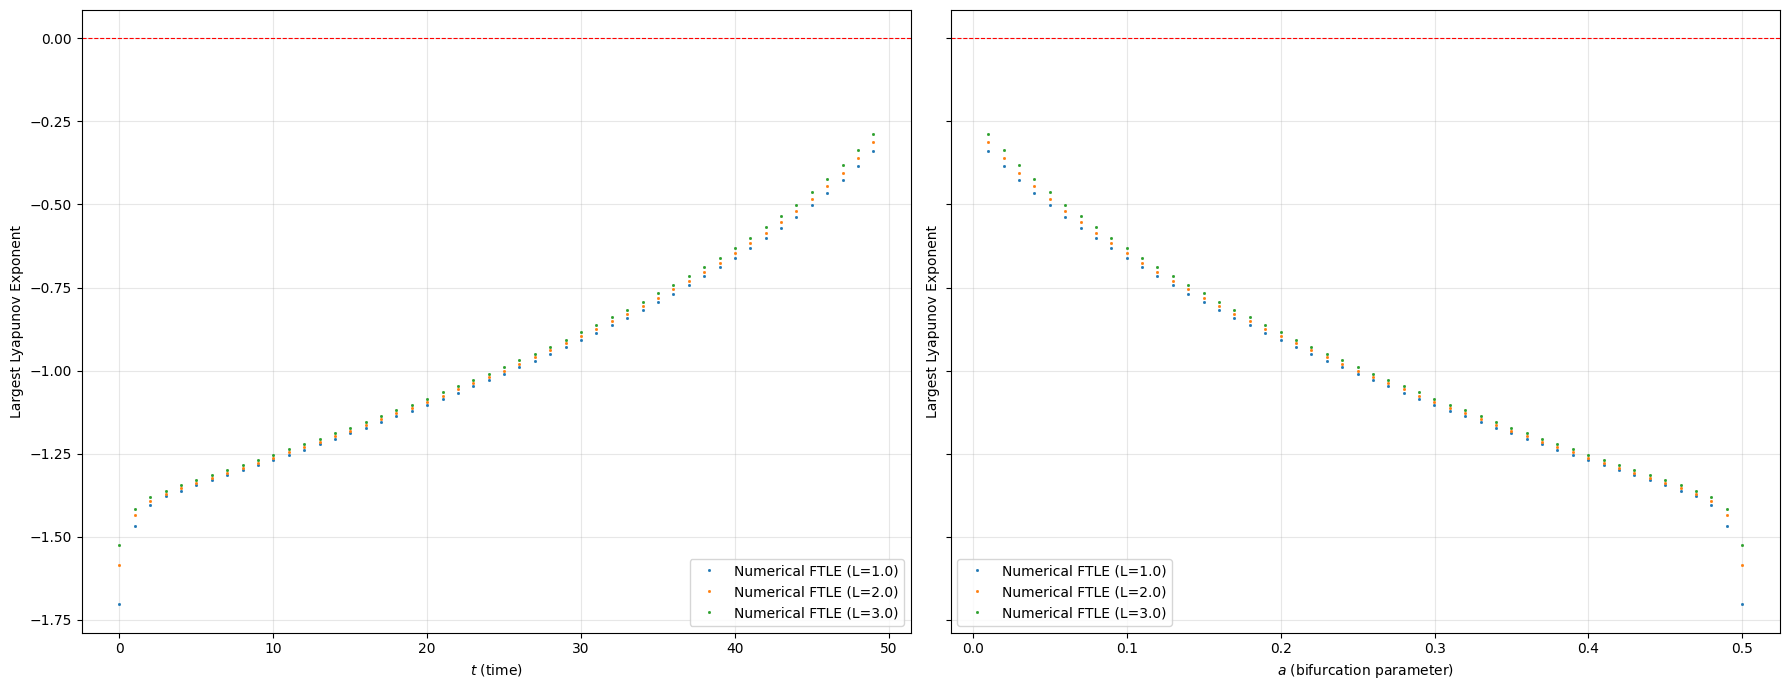

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)



# Left plot - FTLE vs time
for i in range(lle_tensor.shape[0]):
    axes[0].plot(
        t_pts,
        lle_tensor[i, :].detach().cpu(),
        linestyle='',
        marker='s',
        markersize=1,
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )

axes[0].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[0].set_ylabel('Largest Lyapunov Exponent')
axes[0].set_xlabel(r'$t$ (time)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right plot - FTLE vs bifurcation parameter a
for i in range(lle_tensor.shape[0]):
    axes[1].plot(
        a_pts,
        lle_tensor[i, :].detach().cpu(),
        linestyle='',
        marker='s',
        markersize=1,
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )

axes[1].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[1].set_ylabel('Largest Lyapunov Exponent')
axes[1].set_xlabel(r'$a$ (bifurcation parameter)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

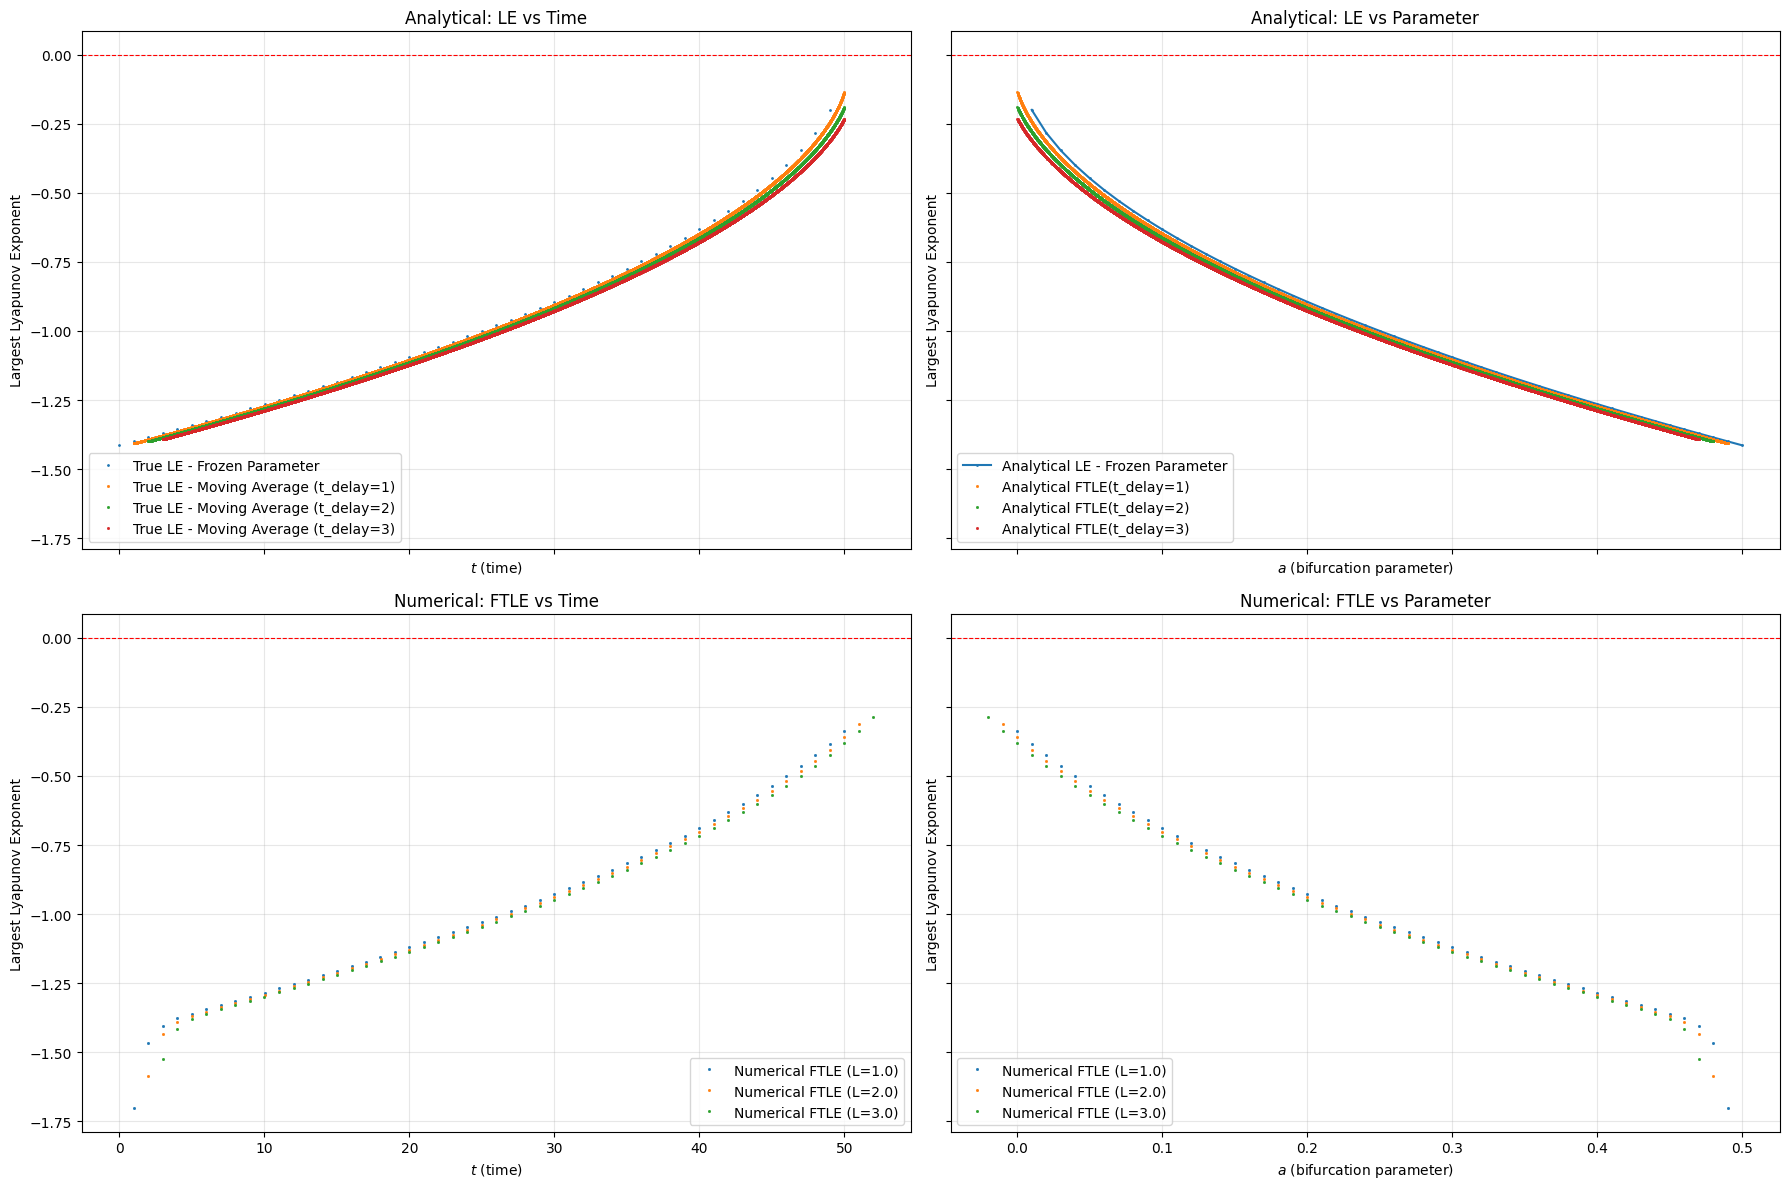

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True, sharex='col')

# -------------------- Top row: Analytical (from Cell 92) --------------------
# Top-left: True LE vs time
axes[0, 0].plot(
    t_pts,
    le_function(a_function(t_pts)),
    linestyle='',
    marker='o',
    markersize=1,
    label='True LE - Frozen Parameter'
)

for i in range(1, 4):
    t_delay_i = i
    t_pts_delay_i = torch.arange(t_delay_i, 50.0, 0.01)
    ma_vals = ma_ed_function(t_pts_delay_i, t_delay=t_delay_i)
    axes[0, 0].plot(
        t_pts_delay_i,
        ma_vals,
        linestyle='',
        marker='s',
        markersize=1,
        label=f'True LE - Moving Average (t_delay={t_delay_i})'
    )

axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[0, 0].set_ylabel('Largest Lyapunov Exponent')
axes[0, 0].set_xlabel(r'$t$ (time)')
axes[0, 0].set_title('Analytical: LE vs Time')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Top-right: True LE vs bifurcation parameter
axes[0, 1].plot(
    a_pts,
    le_function(a_pts),
    linestyle='-',
    marker='o',
    markersize=1,
    label='Analytical LE - Frozen Parameter'
)

for i in range(1, 4):
    t_delay_i = i
    t_pts_delay_i = torch.arange(t_delay_i, 50.0, 0.01)
    ma_vals = ma_ed_function(t_pts_delay_i, t_delay=t_delay_i)
    axes[0, 1].plot(
        a_function(t_pts_delay_i),
        ma_vals,
        linestyle='',
        marker='s',
        markersize=1,
        label=f'Analytical FTLE(t_delay={t_delay_i})'
    )

axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[0, 1].set_ylabel('Largest Lyapunov Exponent')
axes[0, 1].set_xlabel(r'$a$ (bifurcation parameter)')
axes[0, 1].set_title('Analytical: LE vs Parameter')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# -------------------- Bottom row: Numerical (from Cell 113) --------------------
# Bottom-left: Numerical FTLE vs time
for i in range(lle_tensor.shape[0]):
    axes[1, 0].plot(
        t_pts+L_values[i],
        lle_tensor[i, :].detach().cpu(),
        linestyle='',
        marker='s',
        markersize=1,
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )

axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[1, 0].set_ylabel('Largest Lyapunov Exponent')
axes[1, 0].set_xlabel(r'$t$ (time)')
axes[1, 0].set_title('Numerical: FTLE vs Time')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Bottom-right: Numerical FTLE vs bifurcation parameter
for i in range(lle_tensor.shape[0]):
    axes[1, 1].plot(
        a_pts-0.01*L_values[i],
        lle_tensor[i, :].detach().cpu(),
        linestyle='',
        marker='s',
        markersize=1,
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )

axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[1, 1].set_ylabel('Largest Lyapunov Exponent')
axes[1, 1].set_xlabel(r'$a$ (bifurcation parameter)')
axes[1, 1].set_title('Numerical: FTLE vs Parameter')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

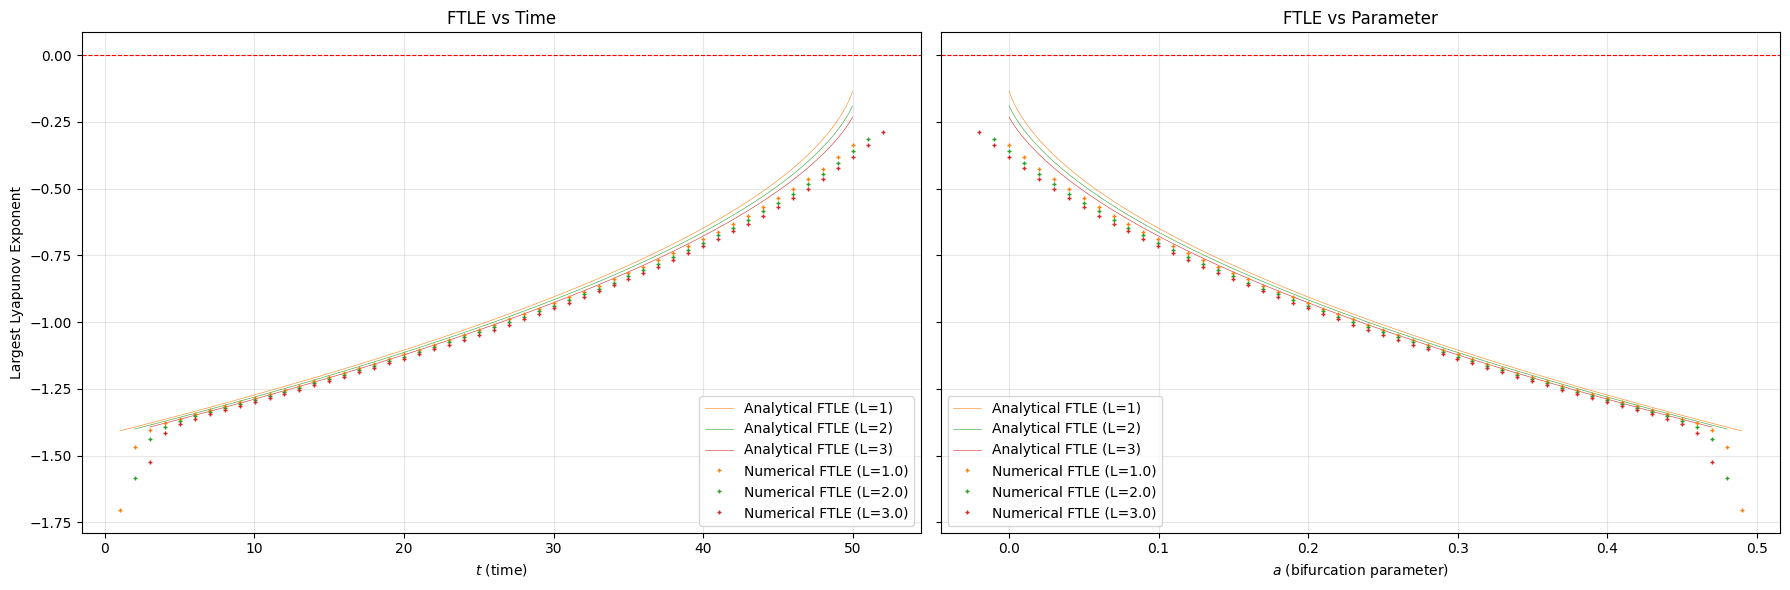

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Define color map for L values
colors = plt.cm.tab10(range(4))  # Use consistent colors for each L value

# Left panel: LE vs time
# Analytical FTLE (lines)
for i in range(1, 4):
    t_delay_i = i
    t_pts_delay_i = torch.arange(t_delay_i, 50.0, 0.01)
    ma_vals = ma_ed_function(t_pts_delay_i, t_delay=t_delay_i)
    axes[0].plot(
        t_pts_delay_i,
        ma_vals,
        linestyle='-',
        linewidth=0.4,
        color=colors[i],
        label=f'Analytical FTLE (L={t_delay_i})'
    )

# Numerical FTLE (+ markers)
for i in range(lle_tensor.shape[0]):
    axes[0].plot(
        t_pts + L_values[i],
        lle_tensor[i, :].detach().cpu(),
        linestyle='',
        marker='+',
        markersize=3,
        color=colors[i+1],
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )

axes[0].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[0].set_ylabel('Largest Lyapunov Exponent')
axes[0].set_xlabel(r'$t$ (time)')
axes[0].set_title('FTLE vs Time')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right panel: LE vs bifurcation parameter
# Analytical FTLE (lines)
for i in range(1, 4):
    t_delay_i = i
    t_pts_delay_i = torch.arange(t_delay_i, 50.0, 0.01)
    ma_vals = ma_ed_function(t_pts_delay_i, t_delay=t_delay_i)
    axes[1].plot(
        a_function(t_pts_delay_i),
        ma_vals,
        linestyle='-',
        linewidth=0.4,
        color=colors[i],
        label=f'Analytical FTLE (L={t_delay_i})'
    )

# Numerical FTLE (+ markers)
for i in range(lle_tensor.shape[0]):
    axes[1].plot(
        a_pts - 0.01 * L_values[i],
        lle_tensor[i, :].detach().cpu(),
        linestyle='',
        marker='+',
        markersize=3,
        color=colors[i+1],
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )

axes[1].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[1].set_xlabel(r'$a$ (bifurcation parameter)')
axes[1].set_title('FTLE vs Parameter')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
saddle_node = ds.saddlenode(a=1, r=0, direction=-1)
saddle_node.f = saddle_node.na_f
sn_analysis = ds.DynamicalSystems_analysis(saddle_node)
saddle_node.dadt = -0.01

In [346]:
def eta(L):
    t_span = (0.0, 50.0)
    dt = 0.01
    traj = sn_analysis.model.solve(
        x0=torch.tensor([-0.3, 0.5], dtype=torch.float32),
        t_span=t_span,
        dt=dt,
        driven=True
    )
    

    step = 1
    step_pts = int(1/dt)
    compute_pts = int(L/dt)
    print(f"Computing LE with L={L} (compute_pts={compute_pts})")

    #Skipping pts 
    skip_pts = int(traj.shape[0] / 20 - compute_pts)
    print(f"Skipping {skip_pts} points to remove transient behavior")
    if skip_pts < 0:
        raise ValueError("Bad parameter values. L too big")

    num_step = int((traj.shape[0] - skip_pts) / step_pts)

    init = torch.stack([
        traj[skip_pts + i * step_pts, :]
        for i in range(num_step-1)
    ], dim=0)

    print(init.shape)
    
    out = sn_analysis.lyapunov_spectrum(
            x0=init.unsqueeze(2),
            k=1,
            t0=0,
            dt=dt,
            num_pts_compute=compute_pts,
            t_transient_pts=0,
            non_autonomous=True
        )
    
    return out, init[:, 1]

In [347]:
eta(1)

Computing LE with L=1 (compute_pts=100)
Skipping 150 points to remove transient behavior
torch.Size([47, 2])


Computing Lyapunov Spectrum: 100%|██████████| 100/100 [00:00<00:00, 1225.40it/s]


(tensor([[-1.3230],
         [-1.3630],
         [-1.3624],
         [-1.3513],
         [-1.3375],
         [-1.3228],
         [-1.3078],
         [-1.2925],
         [-1.2771],
         [-1.2615],
         [-1.2457],
         [-1.2297],
         [-1.2135],
         [-1.1971],
         [-1.1804],
         [-1.1636],
         [-1.1465],
         [-1.1291],
         [-1.1115],
         [-1.0936],
         [-1.0754],
         [-1.0570],
         [-1.0382],
         [-1.0191],
         [-0.9996],
         [-0.9798],
         [-0.9596],
         [-0.9389],
         [-0.9179],
         [-0.8963],
         [-0.8743],
         [-0.8518],
         [-0.8287],
         [-0.8050],
         [-0.7806],
         [-0.7555],
         [-0.7297],
         [-0.7030],
         [-0.6753],
         [-0.6467],
         [-0.6169],
         [-0.5859],
         [-0.5534],
         [-0.5194],
         [-0.4834],
         [-0.4454],
         [-0.4048]]),
 tensor([0.4850, 0.4750, 0.4650, 0.4550, 0.4450, 0.4350, 0

In [351]:
def deta_dL(L, epsilon=0.01):
    L = torch.tensor(L, requires_grad=False)  # Start with no gradient


    eta_L, a_L = eta(L)
    eta_L_plus, a_L_plus = eta(L + epsilon)

    out = (eta_L_plus - eta_L)/ epsilon

    return out 



In [352]:
eta_L = eta(1)
eta_L_plus = eta(1 + 0.01)

Computing LE with L=1 (compute_pts=100)
Skipping 150 points to remove transient behavior
torch.Size([47, 2])


Computing Lyapunov Spectrum: 100%|██████████| 100/100 [00:00<00:00, 1262.28it/s]


Computing LE with L=1.01 (compute_pts=101)
Skipping 149 points to remove transient behavior
torch.Size([47, 2])


Computing Lyapunov Spectrum: 100%|██████████| 101/101 [00:00<00:00, 1275.40it/s]


In [404]:
L = 1

In [406]:
a, a_frozen_le = eta(L)
estimated_frozen_le = L*deta_dL(L) + a

Computing LE with L=1 (compute_pts=100)
Skipping 150 points to remove transient behavior
torch.Size([47, 2])


Computing Lyapunov Spectrum: 100%|██████████| 100/100 [00:00<00:00, 1137.95it/s]


Computing LE with L=1 (compute_pts=100)
Skipping 150 points to remove transient behavior
torch.Size([47, 2])


Computing Lyapunov Spectrum: 100%|██████████| 100/100 [00:00<00:00, 1278.14it/s]


Computing LE with L=1.0099999904632568 (compute_pts=101)
Skipping 149 points to remove transient behavior
torch.Size([47, 2])


Computing Lyapunov Spectrum: 100%|██████████| 101/101 [00:00<00:00, 1276.38it/s]


In [ ]:
L_pts  = torch.arange(0.1, 2.5, 0.1)

In [356]:
list_le = []
list_a = []

In [403]:
L

1

In [358]:
for L in L_pts:
    a, b = eta(L)
    out = L*deta_dL(L) + a
    list_le.append(out)
    list_a.append(b)

Computing LE with L=0.10000000149011612 (compute_pts=10)
Skipping 240 points to remove transient behavior
torch.Size([46, 2])


Computing Lyapunov Spectrum: 100%|██████████| 10/10 [00:00<00:00, 954.18it/s]
/var/folders/sp/j4vszjg52_g2p7ct__xzvwk80000gn/T/ipykernel_96282/3417816303.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L = torch.tensor(L, requires_grad=False)  # Start with no gradient


Computing LE with L=0.10000000149011612 (compute_pts=10)
Skipping 240 points to remove transient behavior
torch.Size([46, 2])


Computing Lyapunov Spectrum: 100%|██████████| 10/10 [00:00<00:00, 1060.56it/s]


Computing LE with L=0.10999999940395355 (compute_pts=11)
Skipping 239 points to remove transient behavior
torch.Size([46, 2])


...

Computing Lyapunov Spectrum: 100%|██████████| 250/250 [00:00<00:00, 1396.99it/s]


Computing LE with L=2.5 (compute_pts=250)
Skipping 0 points to remove transient behavior
torch.Size([49, 2])


Computing Lyapunov Spectrum: 100%|██████████| 250/250 [00:00<00:00, 1395.31it/s]


Computing LE with L=2.509999990463257 (compute_pts=251)
Skipping -1 points to remove transient behavior


ValueError: Bad parameter values. L too big

In [359]:
L

tensor(2.5000)

In [360]:
L = 1
out = L*deta_dL(L) + eta(L)

Computing LE with L=1 (compute_pts=100)
Skipping 150 points to remove transient behavior
torch.Size([47, 2])


Computing Lyapunov Spectrum: 100%|██████████| 100/100 [00:00<00:00, 1264.33it/s]


Computing LE with L=1.0099999904632568 (compute_pts=101)
Skipping 149 points to remove transient behavior
torch.Size([47, 2])


Computing Lyapunov Spectrum: 100%|██████████| 101/101 [00:00<00:00, 1253.52it/s]


Computing LE with L=1 (compute_pts=100)
Skipping 150 points to remove transient behavior
torch.Size([47, 2])


Computing Lyapunov Spectrum: 100%|██████████| 100/100 [00:00<00:00, 1258.73it/s]


TypeError: unsupported operand type(s) for +: 'Tensor' and 'tuple'

In [148]:
t_pts = torch.arange(0, 50.0, 0.01)
a_pts = a_function(t_pts)

delay = 0.5 - a_function(L)

In [159]:
a_pts

tensor([5.0000e-01, 4.9990e-01, 4.9980e-01,  ..., 3.0005e-04, 2.0000e-04,
        1.0005e-04])

In [ ]:
init_tensor[:, 1]

tensor([0.5000, 0.4900, 0.4800, 0.4700, 0.4599, 0.4499, 0.4399, 0.4299, 0.4199,
        0.4099, 0.3999, 0.3899, 0.3799, 0.3699, 0.3599, 0.3499, 0.3399, 0.3299,
        0.3199, 0.3099, 0.2999, 0.2899, 0.2799, 0.2699, 0.2599, 0.2500, 0.2399,
        0.2299, 0.2199, 0.2099, 0.1999, 0.1899, 0.1799, 0.1699, 0.1599, 0.1499,
        0.1399, 0.1299, 0.1199, 0.1099, 0.0999, 0.0899, 0.0799, 0.0699, 0.0599,
        0.0499, 0.0399, 0.0299, 0.0199, 0.0099])

IndexError: list index out of range

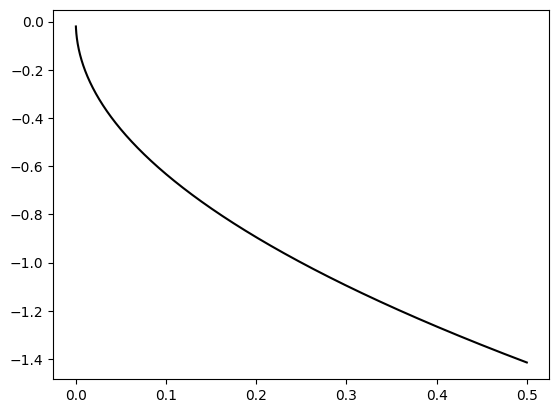

In [388]:
i = i + 1
plt.plot(a_pts, le_function(a_pts), label='True LE (Frozen)', color='k')
plt.plot(list_a[i], list_le[i], linestyle='', marker='+', color='r', markersize=4, label='Estimated True LE (Frozen)')
plt.xlabel('a (bifurcation parameter)')
plt.ylabel('Largest Lyapunov Exponent')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [364]:
# Alternative: Make eta differentiable by avoiding discrete operations
def eta_differentiable(L_continuous):
    """
    Modified version that could work with autograd
    - Takes L as continuous parameter
    - Would need modified lyapunov_spectrum that doesn't use .cpu()
    """
    # Convert L to number of points (still problematic)
    num_pts = torch.floor(L_continuous / dt).long() 
    
    # This will still break gradient flow because:
    # 1. .long() conversion loses gradients
    # 2. num_pts is used as loop counter (discrete)
    
    # Real solution would require:
    # - Reformulating to avoid discrete iteration counts
    # - Using continuous interpolation instead
    # - Or accepting finite differences as the gradient estimate
    
    pass  # Placeholder - not fully implemented

# For practical gradient estimation, finite differences are often simplest:
def compute_eta_gradient_fd(L_values_tensor):
    """Compute gradient using finite differences"""
    epsilon = 0.01
    gradients = []
    
    for L in L_values_tensor:
        eta_L = eta(L)
        eta_L_plus = eta(L + epsilon)
        grad = (eta_L_plus - eta_L) / epsilon
        gradients.append(grad)
    
    return torch.stack(gradients)

# Example usage would be:
# grad_estimates = compute_eta_gradient_fd(L_values[:2])  # Test on first 2 values

In [ ]:
# Interactive widget for browsing Estimated True LE curves

def plot_le_widget(i=0):
    plt.figure(figsize=(8, 5))
    plt.plot(a_pts, le_function(a_pts), label='True LE (Frozen)', color='k')
    plt.plot(
        list_a[i].detach().cpu() if isinstance(list_a[i], torch.Tensor) else list_a[i],
        list_le[i].detach().cpu() if isinstance(list_le[i], torch.Tensor) else list_le[i],
        linestyle='',
        marker='+',
        color='r',
        markersize=4,
        label='Estimated True LE (Frozen)'
    )
    plt.xlabel('a (bifurcation parameter)')
    plt.ylabel('Largest Lyapunov Exponent')
    plt.title(f'i = {i}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

interact(plot_le_widget, i=IntSlider(min=0, max=len(list_a)-1, step=1, value=0));

interactive(children=(IntSlider(value=0, description='i', max=23), Output()), _dom_classes=('widget-interact',…

24

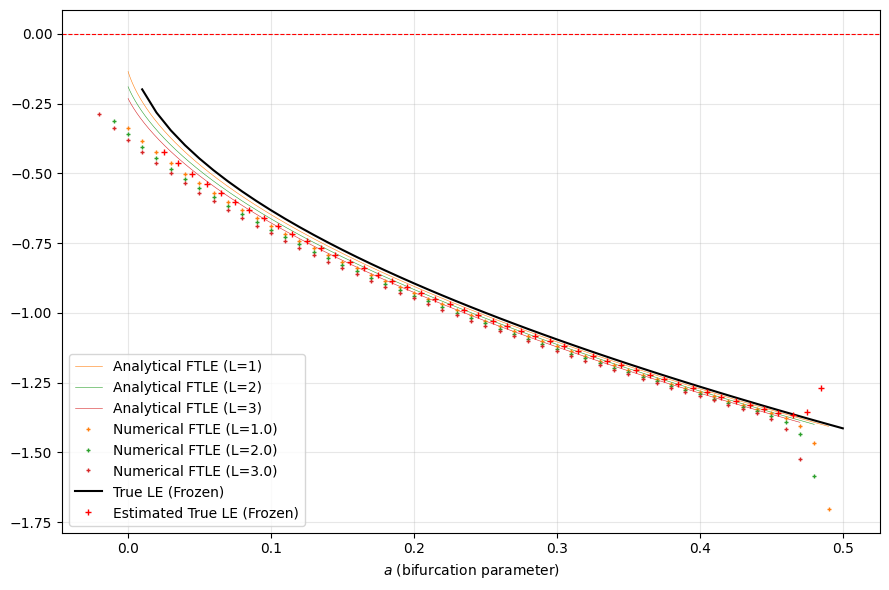

In [407]:
fig, axes = plt.subplots(1, 1, figsize=(9, 6), sharey=True)

# Build axes values from numerical tensors
a_pts = init_tensor[:, 1].detach().cpu()



dadt = -0.01 # From previous fill
t_func = lambda a: (a - 0.5)/dadt
t_pts = t_func(a_pts)

# Define color map for L values
colors = plt.cm.tab10(range(4))  # Use consistent colors for each L value


# Right panel: LE vs bifurcation parameter
# Analytical FTLE (lines)
for i in range(1, 4):
    t_delay_i = i
    t_pts_delay_i = torch.arange(t_delay_i, 50.0, 0.01)
    ma_vals = ma_ed_function(t_pts_delay_i, t_delay=t_delay_i)
    axes.plot(
        a_function(t_pts_delay_i),
        ma_vals,
        linestyle='-',
        linewidth=0.4,
        color=colors[i],
        label=f'Analytical FTLE (L={t_delay_i})'
    )

# Numerical FTLE (+ markers)
for i in range(lle_tensor.shape[0]):
    axes.plot(
        a_pts - 0.01 * L_values[i],
        lle_tensor[i, :].detach().cpu(),
        linestyle='',
        marker='+',
        markersize=3,
        color=colors[i+1],
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )


axes.plot(a_pts, le_function(a_pts), label='True LE (Frozen)', color='k')
axes.plot(a_frozen_le, estimated_frozen_le, linestyle='', marker='+', color='r', markersize=4, label='Estimated True LE (Frozen)')





axes.axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes.set_xlabel(r'$a$ (bifurcation parameter)')
axes.grid(True, alpha=0.3)
axes.legend()

plt.tight_layout()
plt.show()